# Trabalho 02 — Introdução ao Processamento de Imagens
## Formato PPM (Portable PixMap) — Tipo Colorido RGB / P3 (ASCII)

**Disciplina:** Computação Gráfica / Processamento de Imagens Digitais
**Professor:** André Alessandro Stein
**Aluno:** Igor
**Instituição:** IFC — Campus Rio do Sul

### Objetivo

Gerar arquivos de imagem no formato **PPM tipo P3** (variante ASCII do padrão
Portable Bitmap para imagens coloridas RGB), com conteúdo aleatório, nas
seguintes configurações:

| Item | Dimensões        | Intensidades | `maxval` |
|------|------------------|--------------|----------|
| (a)  | 100 × 100        | 16           | 15       |
| (b)  | 1000 × 1000      | 256          | 255      |
| (c)  | 4K (3840 × 2160) | 256          | 255      |

### Referências

- STEIN, A. A.; HECK, C. *Processamento de Imagens Digitais* — slides da disciplina.
- LOPES, J. M. Brisson. *Formatos de Imagem*. DEI — Instituto Superior Técnico,
  Lisboa, 2003 (reeditado 2013). Seção 2 — Formatos PBM.

## 1. Fundamentação: a estrutura do formato P3

A família PBM engloba três formatos sem compressão que compartilham a mesma
estrutura de cabeçalho (LOPES, 2013, seção 2):

| Tipo | Conteúdo                    | ASCII | Binário |
|------|-----------------------------|-------|---------|
| PBM  | Preto e branco (1 bit)      | P1    | P4      |
| PGM  | Tons de cinzento            | P2    | P5      |
| PPM  | Cores (RGB)                 | P3    | P6      |

Este trabalho usa o **P3**. Seus campos, nesta ordem, separados por espaço em
branco (espaço, TAB, CR ou LF):

1. **Magic number** — a cadeia `P3` em ASCII.
2. **Largura** da imagem, em píxeis, notação decimal.
3. **Altura** da imagem, em píxeis, notação decimal.
4. **Valor máximo** das componentes de cor (`maxval`).
5. **Valores dos píxeis** — `largura × altura × 3` valores decimais, pois cada
   píxel é representado pelas três componentes RGB.

### Ordem de varrimento

A ordenação dos valores corresponde ao varrimento **linha a linha, de cima para
baixo**, e **da esquerda para a direita** dentro de cada linha. Ou seja: o
varrimento é descendente, ao contrário do formato DIB/BMP, que é ascendente.

### Regras específicas das variantes ASCII

- Comentários iniciam com `#` e valem até o fim da linha. Podem aparecer em
  qualquer parte do arquivo.
- **O comprimento máximo de cada linha é 70 caracteres.** Essa limitação vem da
  especificação original, que visava transmitir imagens por correio eletrônico
  quando ainda não havia suporte a anexos.

### Sobre o número de intensidades

`maxval` é o **valor máximo**, não a quantidade de níveis. Portanto:

- 16 intensidades → valores no intervalo `[0, 15]` → `maxval = 15`
- 256 intensidades → valores no intervalo `[0, 255]` → `maxval = 255`

In [32]:
#Bibliotecas e configurações globais

import os
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

#Semente fixa: Garante que a execução seja reprodutível.
# Sem isso, cada execução geraria imagem diferentes e o trabalho
# não seria verificável por terceiros
SEMENTE = 42
rng = np.random.default_rng(SEMENTE)

#Diretório de saída
SAIDA = Path("saida")
SAIDA.mkdir(exist_ok=True)

#Limite de coluna imposto pela especificação dar variantes ASCII
LIMITE_COLUNA = 70

print(f"Numpy    : {np.__version__}")
print(f"Diretório: {SAIDA.resolve()}")
print(f"SementeRNG: {SEMENTE}")

Numpy    : 2.5.2
Diretório: /home/igorkg/PycharmProjects/TrabalhoRGBProcessamentoDigitalDeImagem/saida
SementeRNG: 42


## 2. Como respeitar o limite de 70 caracteres por linha

A especificação limita cada linha a 70 caracteres. Como os valores têm largura
variável em notação decimal (`7`, `42`, `255` ocupam 1, 2 e 3 caracteres), há
duas estratégias:

**Estratégia A — acumular tokens e quebrar quando estourar.** Correta, porém
exige verificar o comprimento a cada valor escrito. Custo alto quando há
25 milhões de valores.

**Estratégia B — número fixo de valores por linha, calculado pelo pior caso.**
Se o maior valor possível é `maxval`, então nenhum token excede
`len(str(maxval))` caracteres. Com `n` valores separados por espaço simples, o
pior caso é:

    comprimento_maximo = n * (largura_token + 1) - 1

Basta escolher o maior `n` que satisfaça `comprimento_maximo <= 70`.

Adoto a **estratégia B**, com um refinamento: arredondo `n` para baixo até um
múltiplo de 3. Assim cada linha contém um número inteiro de píxeis RGB, o que
torna o arquivo muito mais legível na inspeção manual.

Resultados:

| `maxval` | largura do token | `n` bruto | `n` ajustado | píxeis/linha | pior caso |
|----------|------------------|-----------|--------------|--------------|-----------|
| 15       | 2                | 23        | 21           | 7            | 62 chars  |
| 255      | 3                | 17        | 15           | 5            | 59 chars  |

In [33]:
def calcular_valores_por_linha(maxval: int, limite_coluna: int = LIMITE_COLUNA) -> int:
    """
    Determina quantos valores cabem em uma linha sem violar o limite de colunas.

    Considera o pior caso (todo token com a largura máxima) e arredonda para
    baixo até um múltiplo de 3, mantendo píxeis RGB inteiros por linha.
    """

    largura_token = len(str(maxval))

    # n * (largura_token + 1) - 1 <= limite_coluna
    n = (limite_coluna + 1) // (largura_token + 1)

    #Arredonda para múltiplo de 3 (Píxeis completos), com mínimo de 1 píxel
    n = max(3, n - (n % 3))
    return n

#Verificação
for mv in (15, 255):
    n = calcular_valores_por_linha(mv)
    pior_caso = n * (len(str(mv)) + 1) - 1
    print(f"maxval = {mv:>3} -> {n:>2} valores/linha"
          f"({n // 3} píxeis), pior caso: {pior_caso} chars")
    assert pior_caso <= LIMITE_COLUNA

maxval =  15 -> 21 valores/linha(7 píxeis), pior caso: 62 chars
maxval = 255 -> 15 valores/linha(5 píxeis), pior caso: 59 chars


## 3. Escrita do arquivo P3

O escritor precisa lidar com duas escalas muito diferentes: 30 mil valores no
item (a) e 25 milhões no item (c). Uma implementação ingênua acumulando tudo em
uma única string exigiria centenas de megabytes de RAM e seria muito lenta.

A solução é **escrever em blocos**. O array é percorrido em fatias, cada fatia é
convertida em texto e imediatamente despejada no arquivo. O tamanho do bloco é
sempre múltiplo de `valores_por_linha`, garantindo que nenhuma quebra de linha
caia no meio de uma linha lógica.

Dois detalhes de implementação que importam:

- `.tolist()` converte a fatia NumPy em uma lista de inteiros nativos de Python.
  Isso é significativamente mais rápido que aplicar `str()` diretamente sobre
  escalares NumPy.
- `newline="\n"` força terminadores Unix mesmo no Windows. Sem isso, o Python
  traduziria `\n` para `\r\n` e a contagem de caracteres por linha mudaria.

In [34]:
def escrever_ppm_p3(caminho, pixels, maxval, comentário=None,
                    limite_coluna=LIMITE_COLUNA, pixels_por_bloco=200_000):

    """
    Grava um array (altura, largura, 3) como arquivo PPM tipo P3 (ASCII).

    Parâmetros
    ----------
    caminho    : destino do arquivo
    pixels     : ndarray de inteiros, shape (altura, largura, 3)
    maxval     : valor máximo das componentes de cor
    comentario : texto opcional inserido como comentário no cabeçalho
    """

    pixels = np.asarray(pixels)

    if pixels.ndim != 3 or pixels.shape[2] != 3:
        raise ValueError(f"Esperado shape (altura, largura, 3), mas recebeu {pixels.shape}")
    if pixels.min() < 0 or pixels.max() > maxval:
        raise ValueError(f"Valores de cor fora do intervalo [0, {maxval}]")

    altura, largura, _ = pixels.shape
    n = calcular_valores_por_linha(maxval, limite_coluna)

    plano = pixels.reshape(-1)        # Varrimento: Linha por Linha, esquerda -> Direita
    tamanho_bloco = n * (pixels_por_bloco // n or 1)

    with open(caminho, "w", encoding="ascii" , newline="\n") as f:
        # --- Cabeçalho ---
        f.write("P3\n")
        if comentário:
            f.write(f"# {comentário}\n")
        f.write(f"{largura} {altura}\n")
        f.write(f"{maxval}\n")

        # --- Conteudo em Blocos ---
        for inicio in range(0, plano.size, tamanho_bloco):
            bloco = plano[inicio:inicio + tamanho_bloco].tolist()
            linhas = [" ".join(map(str, bloco[i:i + n]))
                      for i in range(0, len(bloco), n)]
            f.writelines("\n".join(linhas))
            f.write("\n")

    return caminho

## 4. Leitura e validação

Escrever um arquivo não prova que ele está correto. Implemento um **parser
próprio** — em vez de usar Pillow ou imageio — porque a leitura manual é o que
demonstra compreensão da especificação.

O parser trata o arquivo como um **fluxo de tokens**, não como linhas
estruturadas. Isso é essencial: a spec permite qualquer quantidade de espaços,
TABs e quebras de linha entre os campos, e permite comentários em qualquer
posição. Um parser que assumisse "cabeçalho tem 3 linhas" quebraria em arquivos
perfeitamente válidos gerados por outras ferramentas.

Duas funções:

- `ler_cabecalho_ppm` — lê apenas os metadados. Barato mesmo em arquivos enormes.
- `ler_ppm_p3` — reconstrói a matriz completa. Usado nos itens (a) e (b).

In [35]:
def _fluxo_tokens(arquivos):
    """Gera tokens do arquivo, descartando comentários iniciados por '#'."""
    for linha in arquivos:
        util = linha.split("#", 1)[0]
        for token in util.split():
            yield token

def ler_cabecalho_ppm(caminho):
    """Lê apenas magic number, dimensões e maxval. Não carrega os píxeis."""
    with open(caminho, "r", encoding="ascii") as f:
        it = _fluxo_tokens(f)
        magic = next(it)
        largura, altura, maxval = (int(next(it)) for _ in range(3))
    return {"magic": magic, "largura": largura, "altura": altura, "maxval": maxval}

def ler_ppm_p3(caminho):
    """Lê um arquivo P3 completo e devolve (matriz, maxval)."""
    with open(caminho, "r", encoding="ascii") as f:
        it = _fluxo_tokens(f)

        magic = next(it)
        if magic != "P3":
            raise ValueError(f"Magic number inesperado: {magic!r}")

        largura, altura, maxval = (int(next(it)) for _ in range(3))
        esperado = largura * altura * 3

        dados = np.fromiter(map(int, it), dtype=np.int32, count=esperado)

    return dados.reshape(altura, largura, 3), maxval

def verificar_limite_colunas(caminho, limite=LIMITE_COLUNA):
    """Confere se nenhuma linha do arquivo excede o limite de caracteres."""
    maior = 0
    with open(caminho, "r", encoding="ascii") as f:
        for numero, linha in enumerate(f, start=1):
            comprimento = len(linha.rstrip("\n"))
            if comprimento > limite:
                raise AssertionError(
                    f"Linha {numero} tem {comprimento} caracteres (limite {limite})")
            maior = max(maior, comprimento)
    return maior


In [36]:
# Utilitários de geração, medição e visualização

def gerar_ruido_rgb(largura, altura, maxval, gerador=rng):
    """Gera uma matriz (altura, largura, 3) com valores uniformes em [0, maxval]."""
    dtype = np.uint8 if maxval <= 255 else np.int32
    return gerador.integers(0, maxval + 1, size=(altura, largura, 3), dtype=dtype)

def tamanho_legivel(caminho):
    bytes_ = os.path.getsize(caminho)
    for unidade in ("B", "KB", "MB", "GB"):
        if bytes_ < 1024:
            return f"{bytes_:.1f} {unidade}"
        bytes_ //= 1024
    return f"{bytes_:.1f} TB"

def exibir (imagem, maxval, titulo, tamanho=4):
    """imshow exige float em [0,1]; por isso a normalização por maxval."""
    plt.figure(figsize=(tamanho, tamanho))
    plt.imshow(imagem / maxval)
    plt.title(titulo)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

def histograma_rgb(imagem, maxval, titulo):
    """Histograma por canal — evidencia a uniformidade da distribuição."""
    fig, ax = plt.subplots(figsize=(7, 3))
    for canal, cor in enumerate(("red", "green", "blue")):
        ax.hist(imagem[:, :, canal].ravel(), bins=min(maxval + 1, 256),
                range=(0, maxval + 1), histtype="step", color=cor,
                label=cor.upper())
    ax.set_title(titulo)
    ax.set_xlabel("Intensidade")
    ax.set_ylabel("Frequência")
    ax.legend()
    plt.tight_layout()
    plt.show()

def espiar_arquivo(caminho, linhas=8):
    """Mostra as primeiras linhas do arquivo gerado."""
    with open(caminho, "r", encoding="ascii") as f:
        for _ in range(linhas):
            print(f.readline().rstrip("\n"))

---

## Item (a) — 100 × 100 píxeis, 16 intensidades

- Dimensões: 100 × 100 = **10.000 píxeis**
- Valores no arquivo: 10.000 × 3 = **30.000 valores**
- Intensidades: 16 → intervalo `[0, 15]` → `maxval = 15`

Com 16 níveis por componente, o número de cores representáveis é
16³ = **4.096 cores**. Cada componente ocuparia 4 bits em uma representação
binária compacta, mas no P3 (ASCII) cada valor consome 1 ou 2 caracteres mais o
separador — o custo em disco é muito maior, e é justamente esse o preço da
legibilidade que o formato oferece.

In [37]:
# --- Item (a) ---

LARGURA_A, ALTURA_A, MAXVAL_A = 100, 100, 15
ARQUIVO_A = SAIDA / "a_100x100_16int.ppm"

inicio = time.perf_counter()
imagem_a = gerar_ruido_rgb(LARGURA_A, ALTURA_A, MAXVAL_A)
escrever_ppm_p3(
    ARQUIVO_A, imagem_a, MAXVAL_A,
    comentário=f"item (a) - {LARGURA_A}x{ALTURA_A} - {MAXVAL_A + 1} intensidades"
)
tempo_a = time.perf_counter() - inicio

print(f"Arquivo   : {ARQUIVO_A.name}")
print(f"Tamanho   : {tamanho_legivel(ARQUIVO_A)}")
print(f"Tempo     : {tempo_a:.3f} s")
print(f"Valores   : {imagem_a.size:,}")
print(f"Maior linha: {verificar_limite_colunas(ARQUIVO_A)} caracteres")

Arquivo   : a_100x100_16int.ppm
Tamanho   : 69.0 KB
Tempo     : 0.005 s
Valores   : 30,000
Maior linha: 57 caracteres


Primeiras linhas do arquivo:
--------------------------------------------------------------
P3
# item (a) - 100x100 - 16 intensidades
100 100
15
8 2 13 1 12 15 2 12 12 15 9 10 6 5 5 7 2 1 13 6 12
1 12 13 8 8 0 1 0 11 8 11 14 8 9 3 11 0 1 1 8 5
--------------------------------------------------------------

Round-trip OK: o arquivo lido é idêntico à matriz original.



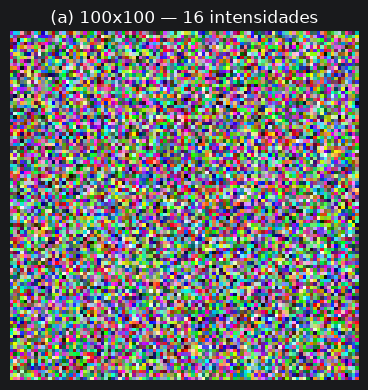

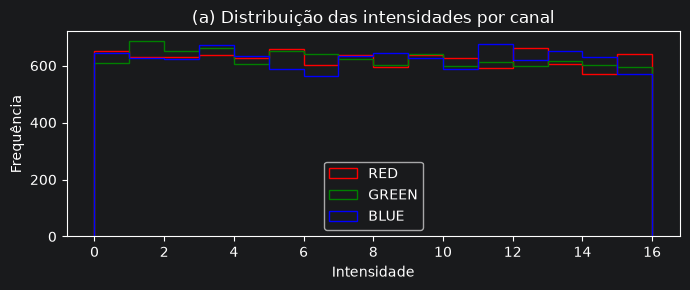

In [38]:
# --- Item (a): inspeção e validação ---

print("Primeiras linhas do arquivo:\n" + "-" * 62)
espiar_arquivo(ARQUIVO_A, linhas=6)
print("-" * 62)

# Round-trip: escrever -> ler -> comparar
lida_a, maxval_lido_a = ler_ppm_p3(ARQUIVO_A)

assert maxval_lido_a == MAXVAL_A
assert lida_a.shape == imagem_a.shape
assert np.array_equal(lida_a, imagem_a)
print("\nRound-trip OK: o arquivo lido é idêntico à matriz original.\n")

exibir(lida_a, MAXVAL_A, f"(a) {LARGURA_A}x{ALTURA_A} — {MAXVAL_A + 1} intensidades")
histograma_rgb(lida_a, MAXVAL_A, "(a) Distribuição das intensidades por canal")

---

## Item (b) — 1000 × 1000 píxeis, 256 intensidades

- Dimensões: 1000 × 1000 = **1.000.000 de píxeis**
- Valores no arquivo: **3.000.000 de valores**
- Intensidades: 256 → intervalo `[0, 255]` → `maxval = 255`

Com 256 níveis por componente chega-se a 256³ = **16.777.216 cores**, o que a
apostila designa por *True Color*. Esse número excede a capacidade de
discriminação da visão humana, motivo pelo qual é considerado suficiente para
imagens de qualidade fotográfica.

Comparação de escala com o item (a): 100 vezes mais píxeis. Vale observar como o
tamanho do arquivo e o tempo de escrita respondem a esse aumento.

Arquivo    : b_1000x1000_256int.ppm
Tamanho    : 10.0 MB
Tempo      : 0.503 s
Valores    : 3,000,000
Maior linha: 59 caracteres
Cabeçalho  : {'magic': 'P3', 'largura': 1000, 'altura': 1000, 'maxval': 255}


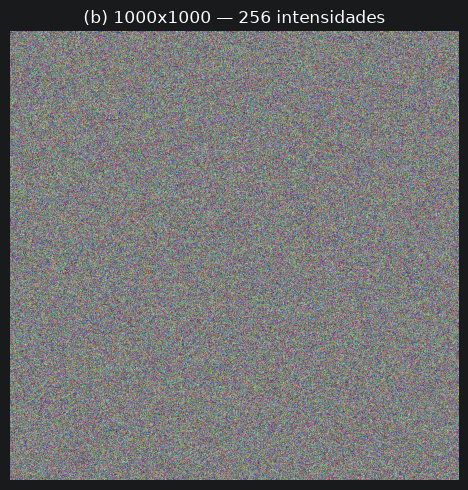

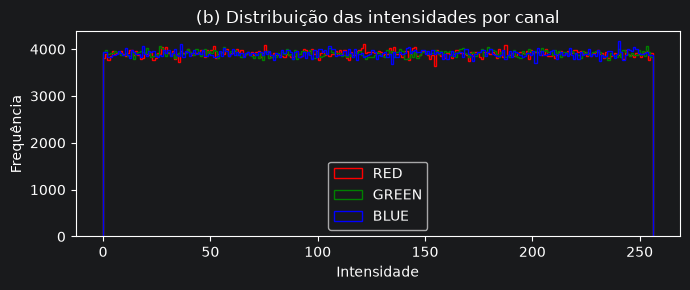

In [39]:
# --- Item (b) ---

LARGURA_B, ALTURA_B, MAXVAL_B = 1000, 1000, 255
ARQUIVO_B = SAIDA / "b_1000x1000_256int.ppm"

inicio = time.perf_counter()
imagem_b = gerar_ruido_rgb(LARGURA_B, ALTURA_B, MAXVAL_B)
escrever_ppm_p3(
    ARQUIVO_B, imagem_b, MAXVAL_B,
    comentário=f"item (b) - {LARGURA_B}x{ALTURA_B} - {MAXVAL_B + 1} intensidades"
)
tempo_b = time.perf_counter() - inicio

print(f"Arquivo    : {ARQUIVO_B.name}")
print(f"Tamanho    : {tamanho_legivel(ARQUIVO_B)}")
print(f"Tempo      : {tempo_b:.3f} s")
print(f"Valores    : {imagem_b.size:,}")
print(f"Maior linha: {verificar_limite_colunas(ARQUIVO_B)} caracteres")

cabecalho_b = ler_cabecalho_ppm(ARQUIVO_B)
print(f"Cabeçalho  : {cabecalho_b}")

exibir(imagem_b, MAXVAL_B, f"(b) {LARGURA_B}x{ALTURA_B} — {MAXVAL_B + 1} intensidades", tamanho=5)
histograma_rgb(imagem_b, MAXVAL_B, "(b) Distribuição das intensidades por canal")

---

## Item (c) — Resolução 4K, 256 intensidades

### Definição da resolução

O termo "4K" é ambíguo. As duas convenções usuais:

| Padrão   | Dimensões   | Píxeis    | Uso                       |
|----------|-------------|-----------|---------------------------|
| UHD-1    | 3840 × 2160 | 8.294.400 | TV, monitores, streaming  |
| DCI 4K   | 4096 × 2160 | 8.847.360 | Cinema digital            |

Adoto **UHD (3840 × 2160)**, que é o significado corrente de "4K" fora do
contexto cinematográfico. A constante abaixo permite trocar para DCI se
necessário.

### O problema da escala

3840 × 2160 × 3 = **24.883.200 valores**.

Estimativa do tamanho em ASCII: com `maxval = 255`, dos 256 valores possíveis,
10 ocupam 1 caractere, 90 ocupam 2 e 156 ocupam 3. A média ponderada é
≈ 2,57 caracteres, mais 1 de separador → **≈ 3,57 bytes por valor**, resultando
em aproximadamente **89 MB**.

Para efeito de comparação, a mesma imagem em P6 (binário) ocuparia
24.883.200 bytes ≈ 23,7 MB — cerca de **3,7 vezes menos**. Esse é exatamente o
compromisso descrito na apostila: os formatos ASCII foram concebidos para
permitir transmissão por correio eletrônico como se fossem texto, ao custo de
"que o tamanho dos ficheiros fosse demasiado grande".

**Atenção:** confira o espaço em disco antes de executar a célula seguinte.

In [40]:
# --- Item (c) ---

# Alterne para (4096, 2160) caso a definição adotada seja DCI 4K
LARGURA_C, ALTURA_C = 3840, 2160
MAXVAL_C = 255
ARQUIVO_C = SAIDA / f"c_{LARGURA_C}x{ALTURA_C}_256int.ppm"

GERAR_4K = True   # ponha False para pular esta etapa

total_valores = LARGURA_C * ALTURA_C * 3
print(f"Píxeis  : {LARGURA_C * ALTURA_C:,}")
print(f"Valores : {total_valores:,}")
print(f"Estimado: ~{total_valores * 3.57 / 1024**2:.0f} MB\n")

if GERAR_4K:
    inicio = time.perf_counter()
    imagem_c = gerar_ruido_rgb(LARGURA_C, ALTURA_C, MAXVAL_C)
    tempo_geracao = time.perf_counter() - inicio

    inicio = time.perf_counter()
    escrever_ppm_p3(
        ARQUIVO_C, imagem_c, MAXVAL_C,
        comentário=f"item (c) - 4K UHD {LARGURA_C}x{ALTURA_C} - {MAXVAL_C + 1} intensidades"
    )
    tempo_escrita = time.perf_counter() - inicio

    print(f"Arquivo        : {ARQUIVO_C.name}")
    print(f"Tamanho real   : {tamanho_legivel(ARQUIVO_C)}")
    print(f"Tempo geração  : {tempo_geracao:.2f} s")
    print(f"Tempo escrita  : {tempo_escrita:.2f} s")
    print(f"Cabeçalho      : {ler_cabecalho_ppm(ARQUIVO_C)}")
    print(f"Maior linha    : {verificar_limite_colunas(ARQUIVO_C)} caracteres")
else:
    print("Geração do 4K desativada (GERAR_4K = False).")

Píxeis  : 8,294,400
Valores : 24,883,200
Estimado: ~85 MB

Arquivo        : c_3840x2160_256int.ppm
Tamanho real   : 84.0 MB
Tempo geração  : 0.02 s
Tempo escrita  : 4.25 s
Cabeçalho      : {'magic': 'P3', 'largura': 3840, 'altura': 2160, 'maxval': 255}
Maior linha    : 59 caracteres


Cabeçalho e primeiras linhas:
--------------------------------------------------------------
P3
# item (c) - 4K UHD 3840x2160 - 256 intensidades
3840 2160
255
192 87 17 117 76 149 89 188 46 163 249 211 243 67 3
7 120 222 150 191 7 69 76 60 184 211 19 69 214 239
--------------------------------------------------------------


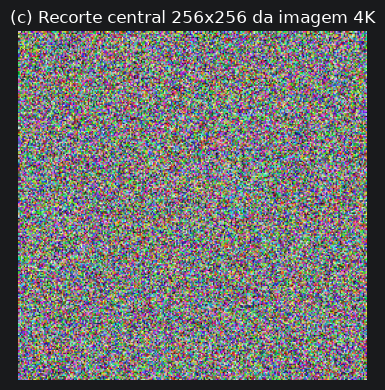

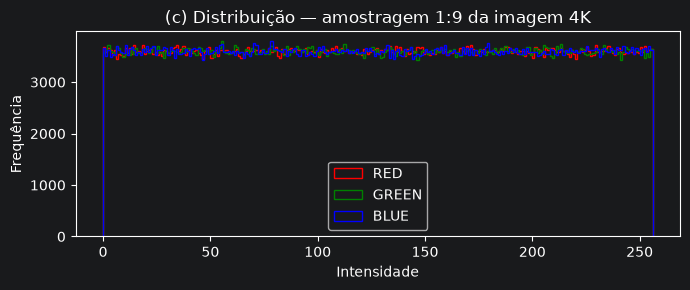

In [41]:
# --- Item (c): inspeção sem carregar o arquivo inteiro ---

if GERAR_4K:
    print("Cabeçalho e primeiras linhas:\n" + "-" * 62)
    espiar_arquivo(ARQUIVO_C, linhas=6)
    print("-" * 62)

    # Recorte central: exibir 8,3 milhões de píxeis não acrescenta informação,
    # já que o conteúdo é ruído uniforme.
    cy, cx = ALTURA_C // 2, LARGURA_C // 2
    recorte = imagem_c[cy - 128:cy + 128, cx - 128:cx + 128]
    exibir(recorte, MAXVAL_C, "(c) Recorte central 256x256 da imagem 4K")

    # Histograma sobre amostra de 1 milhão de píxeis
    amostra = imagem_c[::3, ::3]
    histograma_rgb(amostra, MAXVAL_C, "(c) Distribuição — amostragem 1:9 da imagem 4K")

In [42]:
# --- Quadro comparativo ---

itens = [
    ("(a)", ARQUIVO_A, LARGURA_A, ALTURA_A, MAXVAL_A),
    ("(b)", ARQUIVO_B, LARGURA_B, ALTURA_B, MAXVAL_B),
]
if GERAR_4K:
    itens.append(("(c)", ARQUIVO_C, LARGURA_C, ALTURA_C, MAXVAL_C))

cabecalho = f"{'Item':<5}{'Dimensões':<14}{'Píxeis':>12}{'Valores':>14}" \
            f"{'maxval':>8}{'Tamanho P3':>13}{'P6 (est.)':>12}{'Razão':>8}"
print(cabecalho)
print("-" * len(cabecalho))

for rotulo, caminho, larg, alt, mv in itens:
    px = larg * alt
    valores = px * 3
    bytes_p3 = os.path.getsize(caminho)
    bytes_p6 = valores          # 1 byte por componente quando maxval <= 255
    print(f"{rotulo:<5}{f'{larg}x{alt}':<14}{px:>12,}{valores:>14,}"
          f"{mv:>8}{tamanho_legivel(caminho):>13}"
          f"{bytes_p6 / 1024**2:>11.1f}M{bytes_p3 / bytes_p6:>8.2f}x")

Item Dimensões           Píxeis       Valores  maxval   Tamanho P3   P6 (est.)   Razão
--------------------------------------------------------------------------------------
(a)  100x100             10,000        30,000      15      69.0 KB        0.0M    2.37x
(b)  1000x1000        1,000,000     3,000,000     255      10.0 MB        2.9M    3.57x
(c)  3840x2160        8,294,400    24,883,200     255      84.0 MB       23.7M    3.57x


---

## 5. Discussão e conclusões

### O que foi produzido

Três arquivos PPM P3 válidos, todos verificados por três critérios independentes:

1. **Round-trip** — no item (a), a matriz lida de volta é bit a bit idêntica à
   matriz original, o que confirma que escritor e leitor concordam quanto à
   ordem de varrimento e à codificação.
2. **Cabeçalho** — magic number, dimensões e `maxval` conferidos após a escrita.
3. **Limite de coluna** — nenhuma linha excede os 70 caracteres exigidos pela
   variante ASCII.

### Sobre a natureza do conteúdo

O ruído uniforme é o caso mais desfavorável possível para compressão. Como
observa a apostila, algoritmos do tipo RLE dependem de "grandes grupos de píxeis
consecutivos em que todos os píxeis apresentam a mesma cor", e algoritmos da
família LZ dependem de sequências de cores repetidas. Ruído aleatório não
apresenta nem uma coisa nem outra.

Os histogramas confirmam a uniformidade da distribuição: as três curvas RGB são
aproximadamente planas, sem picos, o que é a assinatura esperada de um gerador
pseudoaleatório uniforme.

### Custo do ASCII

O quadro comparativo torna concreto o custo da representação textual: o P3 ocupa
cerca de 3,6 vezes o espaço do P6 equivalente. Esse fator é o preço da
propriedade que justificou o formato — a possibilidade de inspecionar e editar a
imagem com um editor de texto qualquer, e de transmiti-la por correio eletrônico
como se fosse texto puro.

O item (c) evidencia por que essa decisão de projeto não escala: 89 MB para uma
única imagem sem compressão nenhuma. É exatamente o problema que motivou o
surgimento dos formatos comprimidos descritos nas seções seguintes da apostila
(GIF/LZW, PNG/LZ77, JFIF/JPEG).

### Reprodutibilidade

A semente do gerador é fixa (`SEMENTE = 42`). Reexecutar o notebook produz
arquivos byte a byte idênticos.

In [43]:
# --- Bônus: escritor P6 (binário) para comparação empírica ---

def escrever_ppm_p6(caminho, pixels, maxval, comentario=None):
    """
    Grava a mesma imagem na variante binária (P6).

    No P6 cada componente ocupa exatamente 1 byte, sem separadores entre
    valores consecutivos — o que restringe maxval a 255.
    """
    if maxval > 255:
        raise ValueError("Esta implementação de P6 suporta apenas maxval <= 255")

    pixels = np.asarray(pixels, dtype=np.uint8)
    altura, largura, _ = pixels.shape

    with open(caminho, "wb") as f:
        f.write(b"P6\n")
        if comentario:
            f.write(f"# {comentario}\n".encode("ascii"))
        f.write(f"{largura} {altura}\n{maxval}\n".encode("ascii"))
        f.write(pixels.tobytes())          # varrimento já está correto

    return caminho


ARQUIVO_B_P6 = SAIDA / "b_1000x1000_256int_P6.ppm"
escrever_ppm_p6(ARQUIVO_B_P6, imagem_b, MAXVAL_B, comentario="comparativo P3 vs P6")

p3, p6 = os.path.getsize(ARQUIVO_B), os.path.getsize(ARQUIVO_B_P6)
print(f"P3 (ASCII) : {tamanho_legivel(ARQUIVO_B)}")
print(f"P6 (binário): {tamanho_legivel(ARQUIVO_B_P6)}")
print(f"Razão       : {p3 / p6:.2f}x")

P3 (ASCII) : 10.0 MB
P6 (binário): 2.0 MB
Razão       : 3.57x
